# DX 602 Final Project

## Introduction

In this project, you will practice the skills that you have learned throughout this module with a heavy focus on building models.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform build models, run a computation, or otherwise perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
The Thanksgiving holiday was also taken into account in setting the deadline.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [578]:
import math
import sys

In [579]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - red subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_red))
* [Body Fat](https://www.openml.org/search?type=data&status=active&id=560) ([PMLB](https://github.com/EpistasisLab/pmlb/tree/master/datasets/560_bodyfat))

The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the dataset has missing data, you should drop the rows with missing data before proceeding.
If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [580]:
# YOUR CODE HERE
#Choosing to use the Wine Quality Data Set

file = "https://github.com/EpistasisLab/pmlb/raw/refs/heads/master/datasets/wine_quality_red/wine_quality_red.tsv.gz"
data = pd.read_csv(file, sep="\t")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


YOUR ANSWERS HERE

### Problem 2 (10 points)

List all of the columns and describe them in your own words.

In [581]:
# YOUR CODE HERE
display(data.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000




**Fixed Acidity**: Acid that does not evaporate and cannot be smelled but can be tested.   
**Volatile Acidity**: Acid that does evaporate. This can be smelled and high levels are indicators of bad wine :).  
**Citric Acid**: The name says it all; it is the citric acid content. It might come from the grapes or be added for acidity.  
**Residual Sugar**: The name says it all; The sugar that was unfermented. Basicaly tells how sweet the wine is.  
**Chlorides**: The name says it all; it is the chloride content. It brings saltiness.  
**Free Sulfur Dioxide**: SO2 anybody. It will keep your wine fresh for longer.  
**Total Sulfur Dioxide**: SO2 can be free or bound (attached to other compounds like sugar). This is the sum of those.  
**Density**: Ever heard of the term full-bodied? This is where it comes from. The higher the density, the more concentrated the flavors.  
**Ph**: Acidity indicator.  
**Sulphates**: Sulphates linked to the SO2. Mainly indicates how well the wine will be preserved.  
**Alcohol**: The alcohol content.  
**Target**: Whatever we are trying to predict. I would think it would be the quality of the wine.  

### Problem 3 (50 points)

Perform an exploratory analysis of the data set.
After your exploratory analysis, pick 3 individual charts that you the think were particularly interesting.
Repeat those charts separately from your original analysis, and after each of those charts, explain what you thought was noteworthy.

#### Part 1 - Perform an exploratory analysis of the data set  

In [582]:
#1. What is the shape of the data

print("DATASET OVERVIEW")
print("\n")
print(f"Shape: {data.shape[0]} rows × {data.shape[1]} columns\n")

print("Columns:")
print(data.columns.tolist())
print("\n")

# Missing values
print("Missing Values:")
print(data.isnull().sum())
print(f"\nTotal missing: {data.isnull().sum().sum()}")
print("\n")

# Target variable analysis
print("TARGET VARIABLE ANALYSIS")
print(f"Number of unique quality ratings: {data['target'].nunique()}\n")
print("Distribution of quality ratings:")
print(data['target'].value_counts().sort_index())
print("\n")


DATASET OVERVIEW


Shape: 1599 rows × 12 columns

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'target']


Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
target                  0
dtype: int64

Total missing: 0


TARGET VARIABLE ANALYSIS
Number of unique quality ratings: 6

Distribution of quality ratings:
target
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64




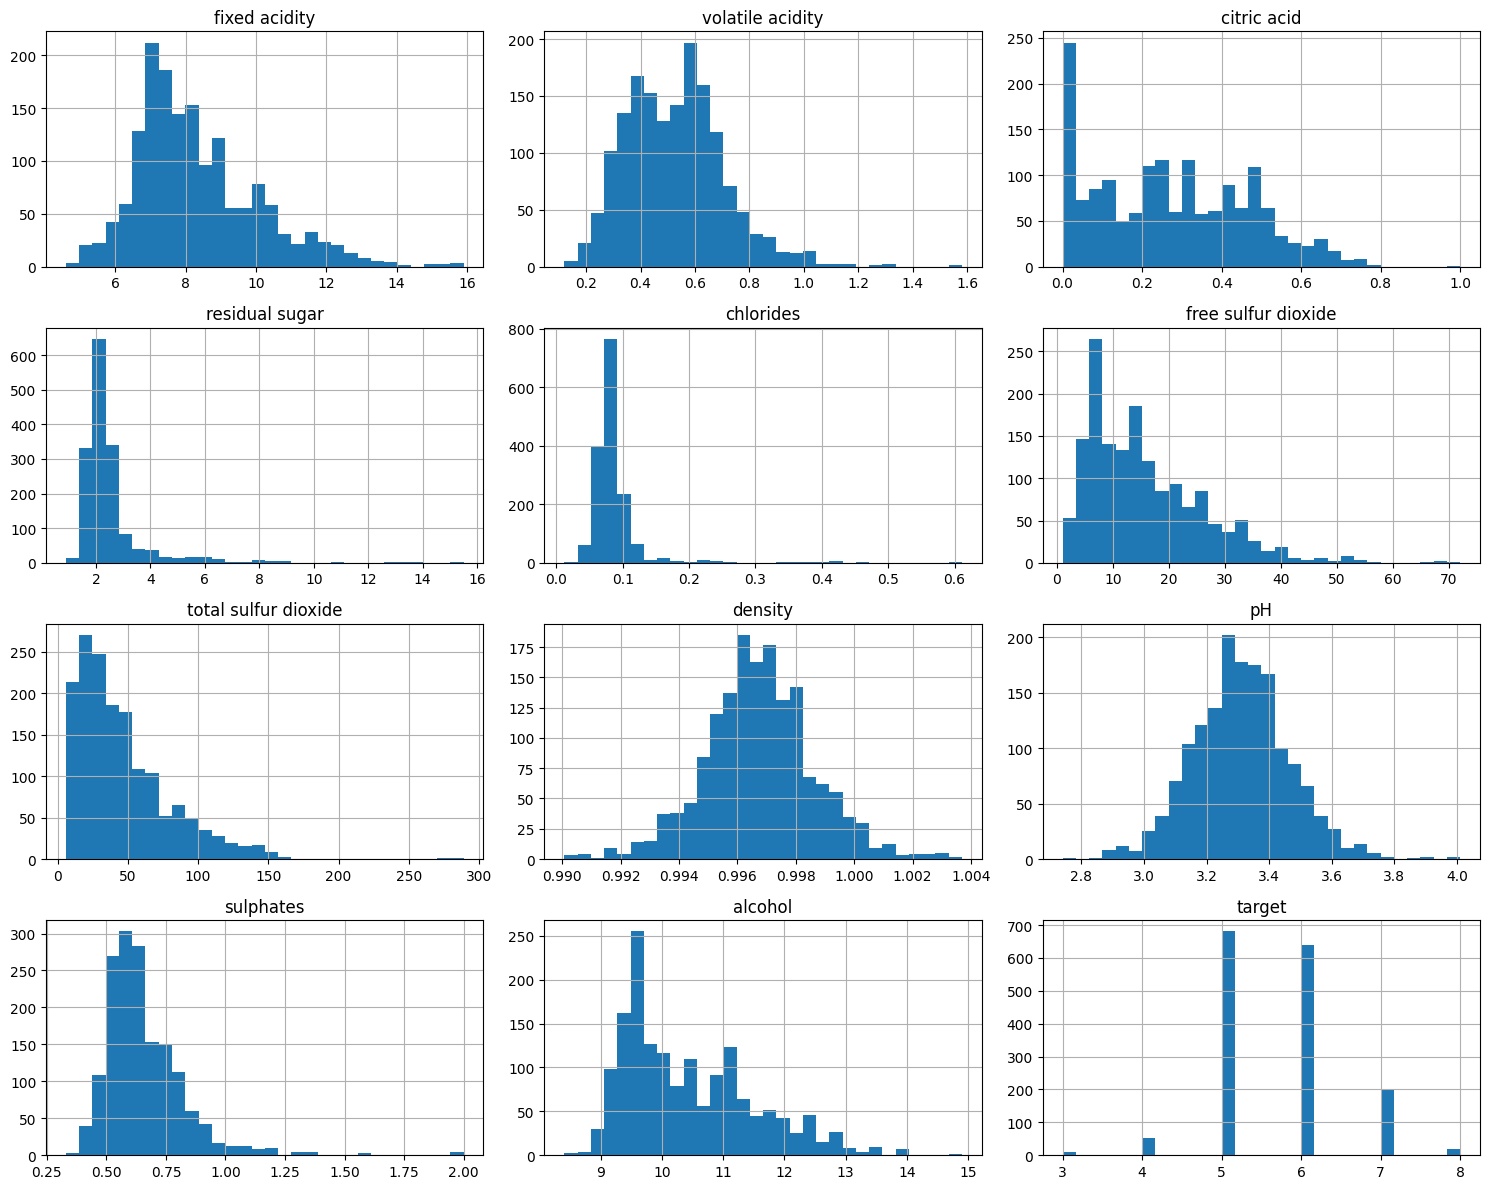

In [583]:
# 2. Distributions of all features
data.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

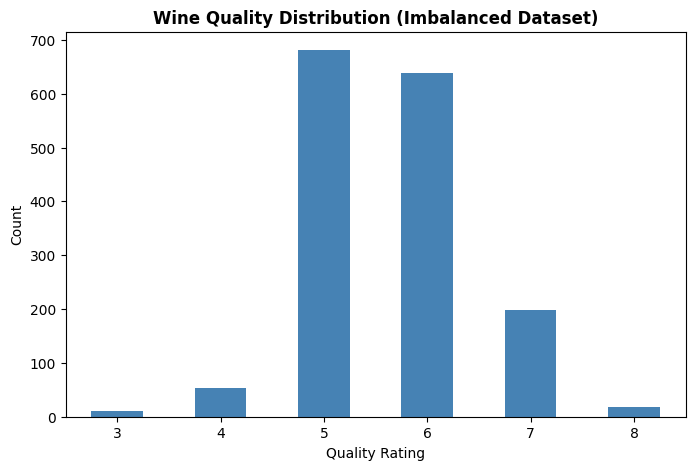

In [584]:
# Target is heavily imbalanced (mostly 5-6)
# 681 wines rated 5, but only 10 rated 3 and 18 rated 8. This will affect model performance.
plt.figure(figsize=(8, 5))
data['target'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Wine Quality Distribution (Imbalanced Dataset)', fontweight='bold')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

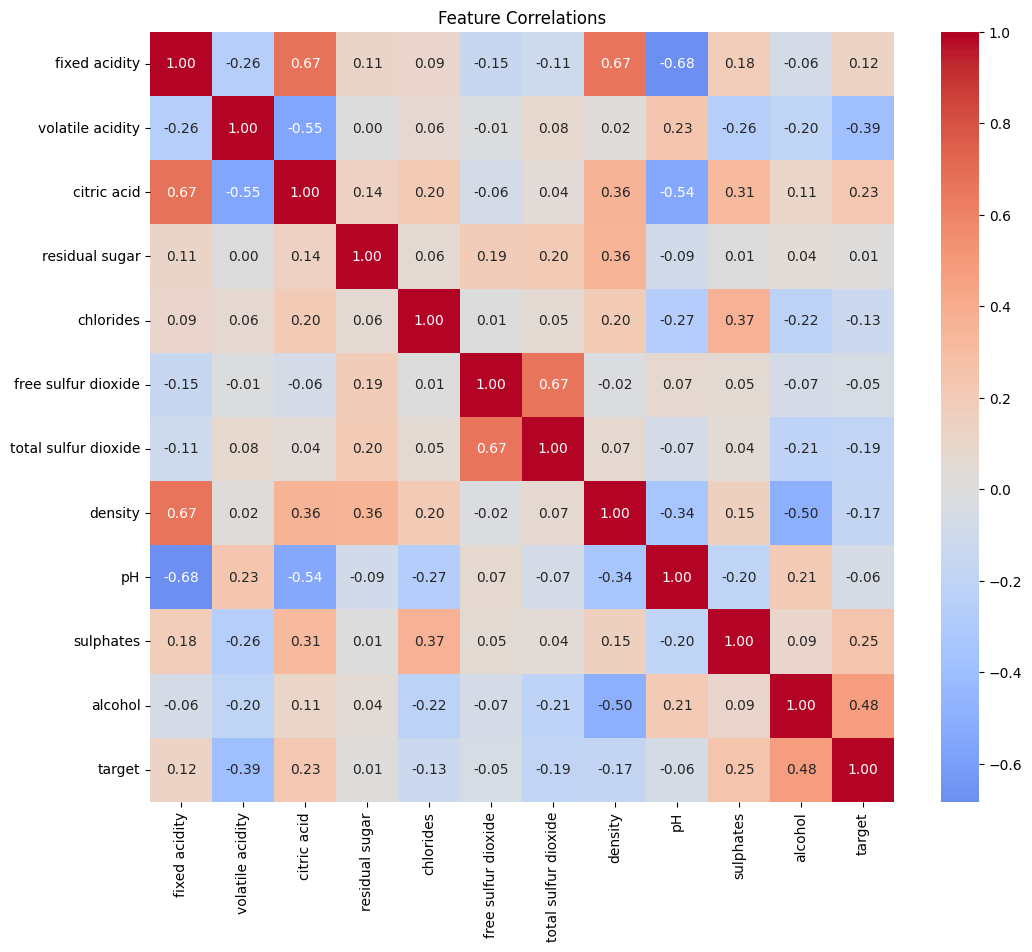

In [585]:
# 3. Correlation heatmap ( this will be used again but just here to view correlations)
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.show()

top_features : (picked using feature correlations) ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']


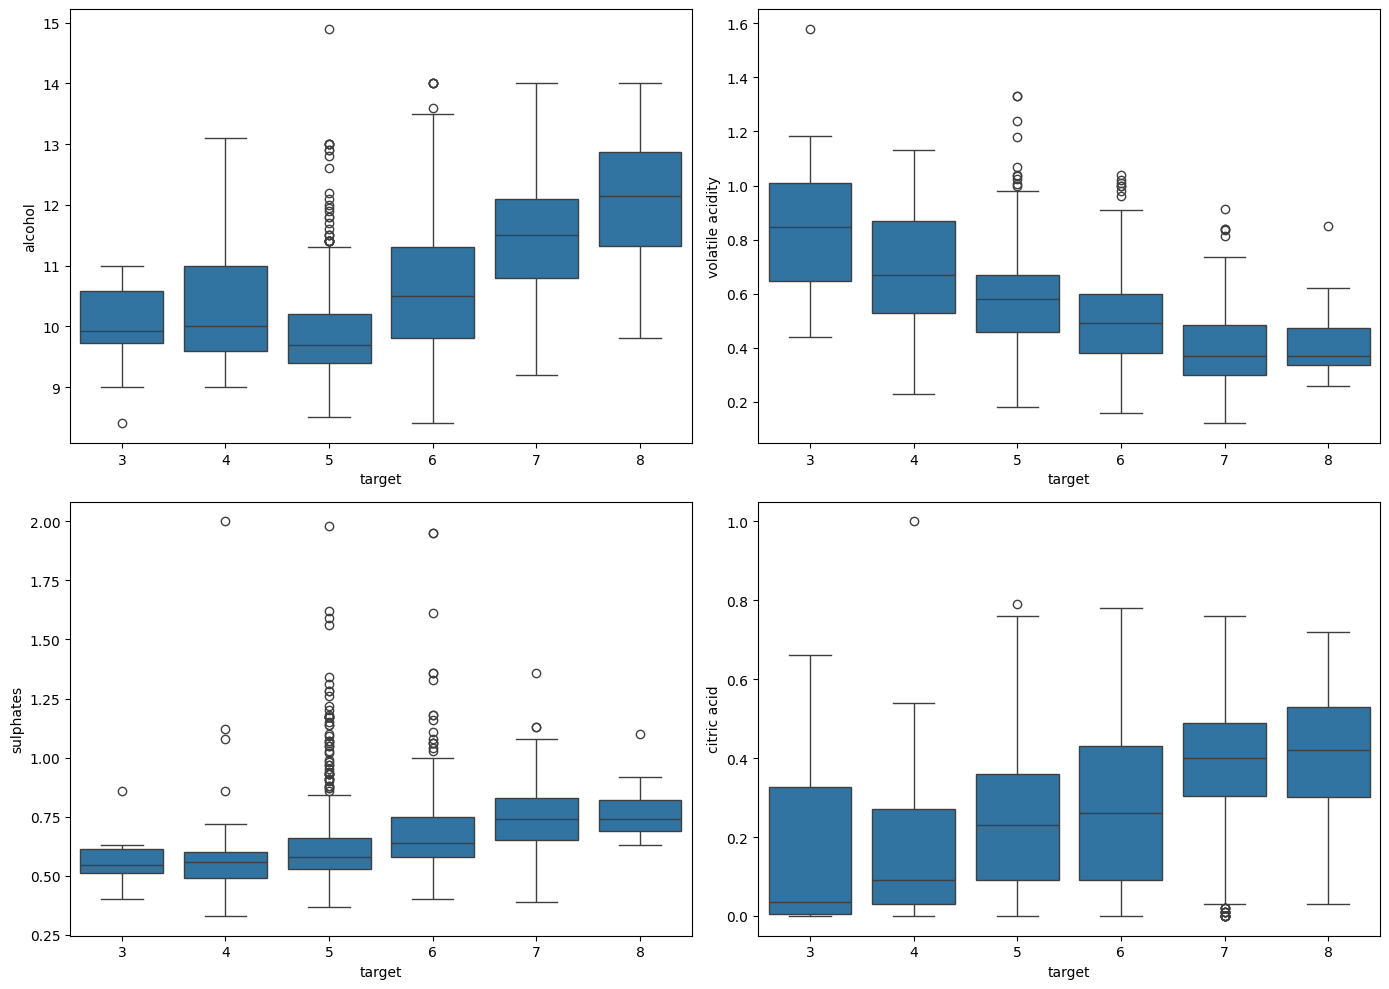

In [586]:
# Key features vs Target (likely suspects picked using Feature Correlations)

top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
print(f"top_features : (picked using feature correlations) {top_features}")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(x='target', y=top_features[0], data=data, ax=axes[0,0])
sns.boxplot(x='target', y=top_features[1], data=data, ax=axes[0,1])
sns.boxplot(x='target', y=top_features[2], data=data, ax=axes[1,0])
sns.boxplot(x='target', y=top_features[3], data=data, ax=axes[1,1])
plt.tight_layout()
plt.show()


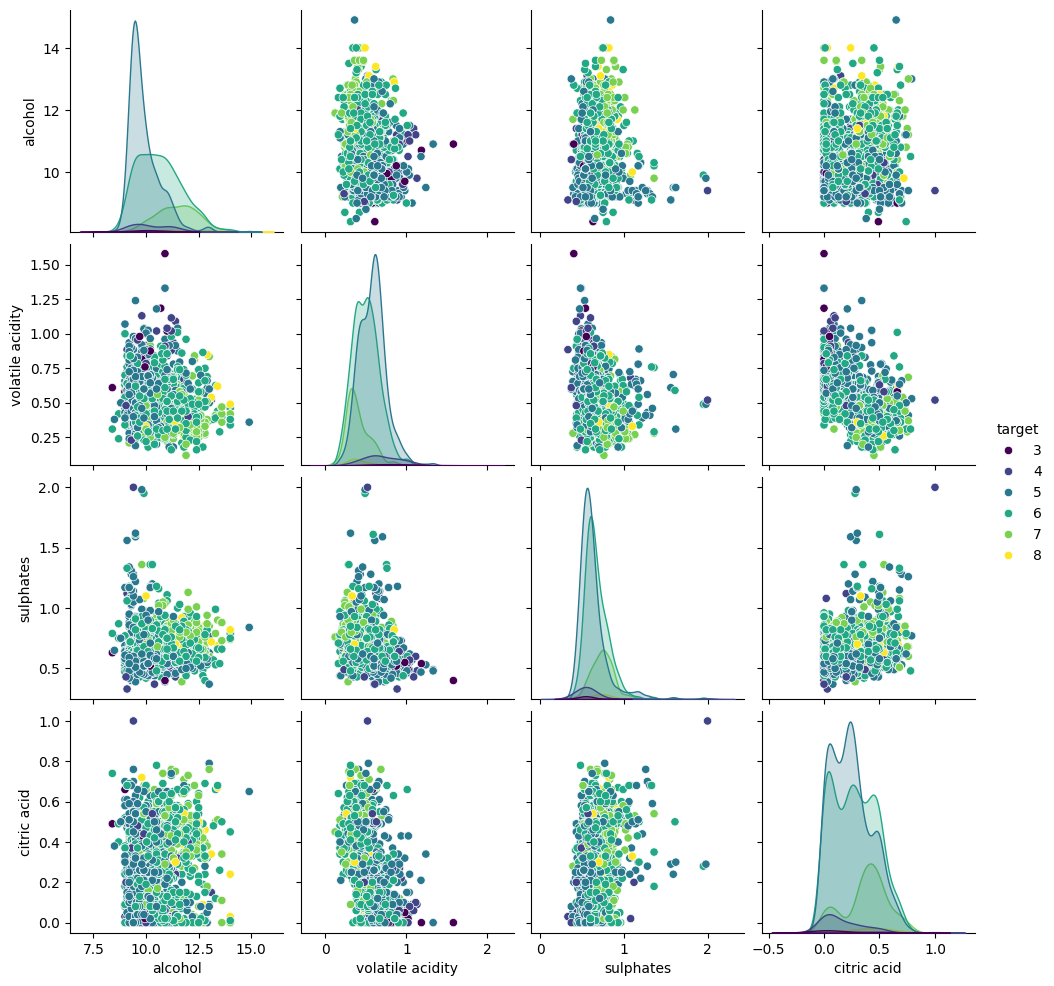

In [587]:
# Pairplot of Top 4 Correlated Features
sns.pairplot(data[top_features + ['target']], hue='target', palette='viridis')
plt.show()

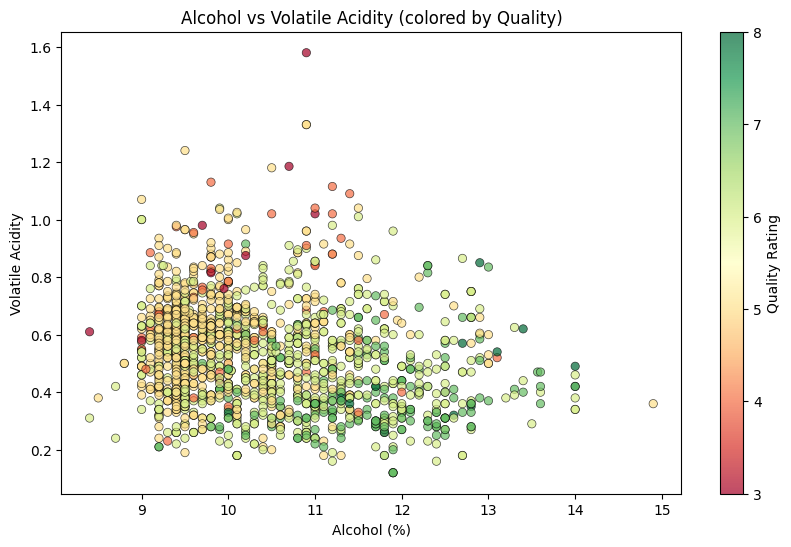

In [588]:
# Top 2 correlated features
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data['alcohol'], data['volatile acidity'], 
                     c=data['target'], cmap='RdYlGn', alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Quality Rating')
plt.xlabel('Alcohol (%)')
plt.ylabel('Volatile Acidity')
plt.title('Alcohol vs Volatile Acidity (colored by Quality)')
plt.show()

#### Part 2 - Three Most Noteworthy Findings

* Correlation heatmap (reduced )
* Target imbalance chart
* Scatter: alcohol vs volatile acidity


##### Correlation Heat Map

<Axes: >

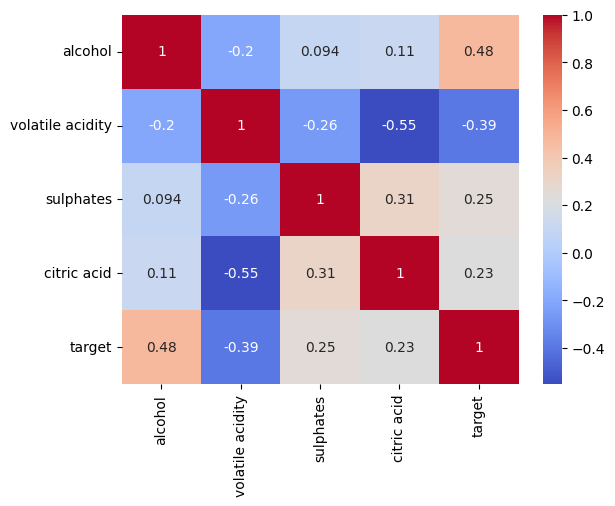

In [589]:

# Zoom into your top 4 features + target
sns.heatmap(data[top_features + ['target']].corr(), annot=True, cmap='coolwarm')



<h3> Chart 1: Correlation Heatmap (Top Features)</h3>
<h4>What's Noteworthy:</h4>

This heatmap highlights features with the strongest correlations to wine quality, which will have the biggest impact when building predictive models. 

* Alcohol content shows the strongest positive correlation `(+0.48)`, indicating that higher-alcohol wines tend to receive better ratings.
* Volatile acidity shows the strongest negative correlation `(-0.39)`, indicating that wines with higher volatile acidity, often a sign of spoilage, receive lower quality scores. 

Focusing on these high-impact features lets us prioritize the variables most likely to drive accurate predictions in our model.

##### Target imbalance chart

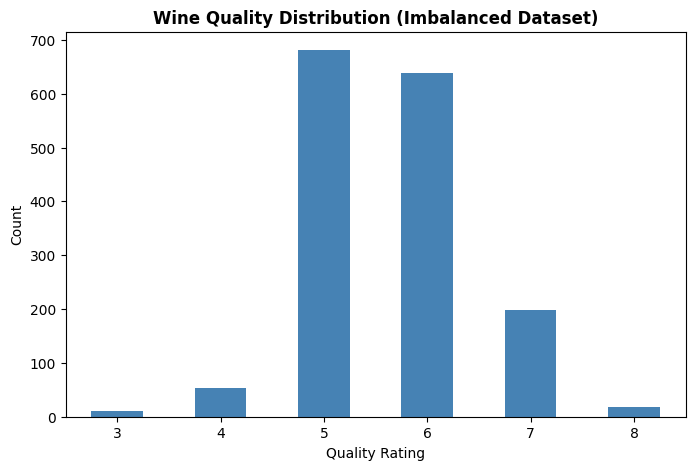

In [590]:
# Target is heavily imbalanced (mostly 5-6)
# 681 wines rated 5, but only 10 rated 3 and 18 rated 8. This will affect model performance.
plt.figure(figsize=(8, 5))
data['target'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Wine Quality Distribution (Imbalanced Dataset)', fontweight='bold')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

<h3>Chart 2: Target Distribution (Quality Imbalance)</h3>
<h4>What's Noteworthy:</h4>

The dataset is heavily imbalanced, and the chart shows that. 

With the majority of wines rated average quality (5-6), accounting for over 82% of all samples. 
In contrast, there are only 10 wines rated 3 and 18 wines rated 8, creating extreme scarcity at both ends of the quality spectrum. 

This imbalance poses a significant challenge for model development: 
the models will be biased toward predicting average-quality wines and will struggle to accurately identify exceptional or poor-quality wines due to limited training examples. 

Addressing this imbalance through techniques such as oversampling, undersampling, or class weighting will be critical to building a robust classifier.

##### Scatter: alcohol vs volatile acidity

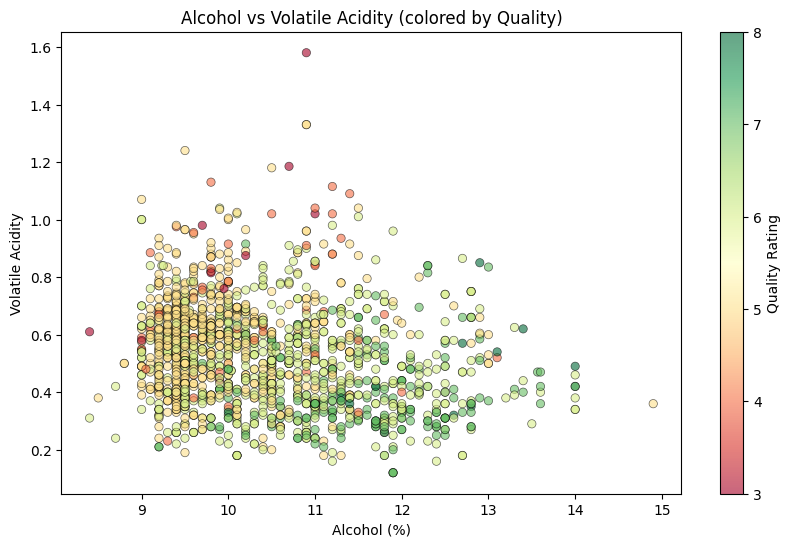

In [591]:
# Top 2 correlated features
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data['alcohol'], data['volatile acidity'], 
                     c=data['target'], cmap='RdYlGn', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Quality Rating')
plt.xlabel('Alcohol (%)')
plt.ylabel('Volatile Acidity')
plt.title('Alcohol vs Volatile Acidity (colored by Quality)')
plt.show()



<h3>Chart 3: Chart 3: Alcohol vs Volatile Acidity Scatter Plot</h3>
<h4>What's Noteworthy:</h4>

This scatter plot examines the two strongest predictors of wine quality. While there's a general trend showing higher-quality wines have more alcohol and less volatile acidity, the severe class imbalance (~ 80% of wines rated 5-6) makes it difficult to see a clear separation between quality levels. 

Most points cluster around the average, with very few high- or low-quality wines to establish distinct patterns. 

This visualization reinforces the challenge identified in the target distribution: building a model that accurately distinguishes exceptional from poor wines will be difficult when training data is dominated by average-quality examples.

### Problem 4 (5 points)

Plot the correlation matrix of the numeric columns in the data set.
Which pair of different columns were highlighted as the most correlated?

#### Correlation matrix 

In [592]:
data.head()
# YOUR CODE HERE
# Plot the correlation matrix of the numeric columns in the data set
corr_matrix = data.corr()
#Use the corr_matrix to pick values with visible dependeny 
corr_matrix.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


#### Most correlated

'Most correlated: fixed acidity & pH at -0.6830'

,Feature 1,Feature 2,Correlation
0,fixed acidity,pH,-0.6830


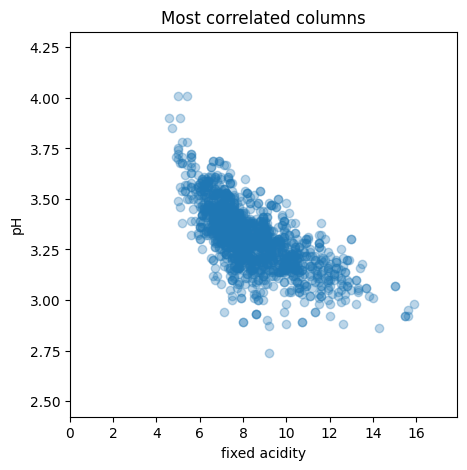

In [593]:
# Which pair of different columns were highlighted as the most correlated?
# Maybe There are better ways to do this, but other than visually validating 
corr_stacked = corr_matrix.stack()
#filter self corrilation 
corr_stacked = corr_stacked[corr_stacked.index.map(lambda x: x[0] != x[1])]
most_correlated = corr_stacked.abs().idxmax()

#print 
column_1 = most_correlated[0]
column_2 = most_correlated[1]
display(f"Most correlated: {column_1} & {column_2} at {corr_matrix.loc[column_1, column_2]:.4f}")
result_df = pd.DataFrame({
    'Feature 1': [column_1],
    'Feature 2': [column_2],
    'Correlation': [f"{corr_matrix.loc[column_1, column_2]:.4f}"]
})
display(result_df)


#Plot 
x = data[column_1]
y = data[column_2]

plt.figure(figsize=(5, 5)) 
plt.scatter(x, y, alpha=0.3)
plt.xlabel(column_1)
plt.ylabel(column_2)
plt.ylim(y.min()-(y.max()-y.min())/4, y.max()+ (y.max()-y.min())/4) 
plt.xlim(0, x.max() + 2 )
_ = plt.title('Most correlated columns')

### Problem 5 (10 points)

Pick three different regression model classes to try in problem 6 from the scikit-learn documentation.
For each class, provide a link to the scikit-learn documentation, and a link to another web page describing how that kind of model works.
The second link should not be from scikit-learn, but Wikipedia is acceptable.
You do not need to understand the methods at this time, but it is good to be comfortable researching them.

In [594]:
models_research = pd.DataFrame({
    'Model': [
        'LinearRegression',
        'RandomForestRegressor',
        'SVR'
    ],
    'Model Description': [
        'https://scikit-learn.org/stable/modules/linear_model.html',
        'https://scikit-learn.org/stable/modules/ensemble.html',
        'https://scikit-learn.org/stable/modules/svm.html'
    ],
    'Scikit-learn Docs': [
        'https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html',
        'https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html',
        'https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html'
    ],
    'Explanation Link': [
        'https://en.wikipedia.org/wiki/Linear_regression',
        'https://en.wikipedia.org/wiki/Random_forest',
        'https://en.wikipedia.org/wiki/Support_vector_machine'
    ]
})

# Make links clickable
def make_clickable(url):
    return f'<a href="{url}" target="_blank">{url}</a>'

models_research_styled = models_research.style.format({
    'Model Description': make_clickable,
    'Scikit-learn Docs': make_clickable,
    'Explanation Link': make_clickable
})

print('\n' + '='*100 + '\n')
display(models_research_styled)
print('\n' + '='*100 + '\n')


,Model,Model Description,Scikit-learn Docs,Explanation Link
0,LinearRegression,https://scikit-learn.org/stable/modules/linear_model.html,https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html,https://en.wikipedia.org/wiki/Linear_regression
1,RandomForestRegressor,https://scikit-learn.org/stable/modules/ensemble.html,https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html,https://en.wikipedia.org/wiki/Random_forest
2,SVR,https://scikit-learn.org/stable/modules/svm.html,https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html,https://en.wikipedia.org/wiki/Support_vector_machine


YOUR ANSWERS HERE

## Questions 6-8: Shared Setup

**Note:** Questions 6-8 use common preprocessing and model setup code. All shared functions and data preparation are defined here to avoid repetition across individual question sections.


In [595]:
from enum import Enum
import sklearn.linear_model
import sklearn.ensemble
import sklearn.tree
import sklearn.svm
import sklearn.neighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error

class ModelType(Enum):
    LINEAR = "linear"
    DECISION_TREE = "decision_tree"
    RANDOM_FOREST = "random_forest"
    RIDGE = "ridge"
    LASSO = "lasso"
    GRADIENT_BOOSTING = "gradient_boosting"
    KNN = "knn"
    SVR = "svr"

model_map = {
    ModelType.LINEAR: sklearn.linear_model.LinearRegression(),
    ModelType.DECISION_TREE: sklearn.tree.DecisionTreeRegressor(random_state=42, max_depth=10),
    ModelType.RANDOM_FOREST: sklearn.ensemble.RandomForestRegressor(random_state=42, n_estimators=100),
    ModelType.RIDGE: sklearn.linear_model.Ridge(alpha=1.0),
    ModelType.LASSO: sklearn.linear_model.Lasso(alpha=1.0),
    ModelType.GRADIENT_BOOSTING: sklearn.ensemble.GradientBoostingRegressor(random_state=42, n_estimators=100),
    ModelType.KNN: sklearn.neighbors.KNeighborsRegressor(n_neighbors=5),
    ModelType.SVR: sklearn.svm.SVR(kernel='rbf'),
}
# Sticking to this three for now
selected_models = [ModelType.LINEAR, ModelType.RANDOM_FOREST, ModelType.SVR]
#selected_models = ModelType

def get_model(model_type: ModelType):
    """Factory function to create model instances."""
    return model_map[model_type]

class ModelResult:
    """Container for model training results."""
    
    def __init__(self, model_name,  predictions,target, l1_loss, l2_loss, r2_score):
        self.model_name = model_name
        self.target = target
        self.predictions = predictions
        self.l1_loss = l1_loss
        self.l2_loss = l2_loss
        self.r2_score = r2_score

    _results_df = None
    
    def append_to_results(self, label: str, description: str = None):
        """Append this result to the class-level results DataFrame"""
        new_row = pd.DataFrame([{
            'Label': label,
            'description': description,
            'Model': self.model_name,
            'L1 Loss': self.l1_loss,
            'L2 Loss': self.l2_loss,
            'R2 Score': self.r2_score
        }])

        if ModelResult._results_df is None:
            ModelResult._results_df = new_row
        else:
            ModelResult._results_df = pd.concat([ModelResult._results_df, new_row], ignore_index=True)
    

    @classmethod
    def get_results_df(cls, label: str = None) -> pd.DataFrame:
        """Get the accumulated results DataFrame"""
        df = cls._results_df.copy()
    
        if label is not None:
            df = df[df['Label'] == label]
        return df
    
    @classmethod
    def clear_results(cls, label: str = None):
        """Clear the accumulated results"""
        if label is not None and cls._results_df is not None:
            cls._results_df = cls._results_df[cls._results_df['Label'] != label]
        else:
            cls._results_df = None


    def __repr__(self):
        return (f"ModelResult(model={self.model_name}, "
                f"L1={self.l1_loss:.4f}, L2={self.l2_loss:.4f}, "
                f"R²={self.r2_score:.4f})")

def plot_multiple_models(results_list):
    """Plot actual vs predicted for multiple models with loss metrics."""
    n_models = len(results_list)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    for ax, result in zip(axes, results_list):
        # Plot actual vs predicted
        max_val = max(result.predictions.max(), result.target.max())
        ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', alpha=0.7)
        ax.scatter(result.predictions, result.target, alpha=0.5)
        
        # Add loss metrics as text
        textstr = f'L1: {result.l1_loss:.2f}\nL2: {result.l2_loss:.2f}\nR²: {result.r2_score:.3f}'
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'{result.model_name}')
    
    plt.tight_layout()
    plt.show()

def compare_l2_results_summary(left: str, right: str, chanage_title):
     metric = 'L2 Loss'
     compare_results_summary(metric, left, right, chanage_title)
def compare_r2_results_summary(left: str, right: str, chanage_title):
     metric = 'R2 Score'
     compare_results_summary(metric, left, right, chanage_title)

def compare_results_summary(metric:str, left: str, right: str, chanage_title):
   
    df = ModelResult.get_results_df()
    print('\n' + '='*100)
    print(f'SUMMARY: Models That Changed Performance ({metric}) After {chanage_title} ({left} vs {right})')
    print('='*100 + '\n')
    
    # Filter to only left and right labels
    df = df[df['Label'].isin([left, right])]
    pivot = df.pivot(index='Model', columns='Label', values=metric)
    pivot['Difference'] = pivot[right] - pivot[left]
    pivot['% Change'] = (pivot['Difference'] / pivot[left]) * 100
    pivot['Changed'] = pivot['% Change'].abs() > 0.1

     # Print formatted summary
    for model in pivot.index:
        left_val = pivot.loc[model, left]
        right_val = pivot.loc[model, right]
        diff = pivot.loc[model, 'Difference']
        pct = pivot.loc[model, '% Change']
        changed = "YES" if pivot.loc[model, 'Changed'] else "NO"
        
        print(f"{model:20s} | {left}: {left_val:.6f} | {right}: {right_val:.6f} | "
                f"Diff: {diff:+.6f} | Change: {pct:+.2f}% | Changed: {changed}")
        
    print()

    pivot[[left, right]].plot(kind='bar', figsize=(10, 6))
    plt.ylabel(metric)
    plt.title(f'{metric} Comparison: {left} vs {right}')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Label')
    plt.tight_layout()
    plt.show()


def results_summary(label: str = None) -> pd.DataFrame:
    """Get the accumulated results DataFrame"""
    results_df = ModelResult.get_results_df(label)
    print(f"{label} Results - Sorted by L2 Loss")
    display(results_df.sort_values('L2 Loss'))
    print('='*100 + '\n')


### Problem 6 (50 points)

Build three different regression models using the entire data set.
Plot the actual target vs the predicted values for each in one chart.
Compute the L2 and L1 losses for each of them.
You may use any regression class provided provided by scikit-learn, and you may reuse one class as long as you change its parameters enough to see different results.

#### Three different regression models using the entire data set.

P6 Results - Sorted by L2 Loss


,Label,description,Model,L1 Loss,L2 Loss,R2 Score
1,P6,None,random_forest,0.148061,0.045205,0.930642
0,P6,None,linear,0.500490,0.416767,0.360552
2,P6,None,svr,0.546291,0.523133,0.197354


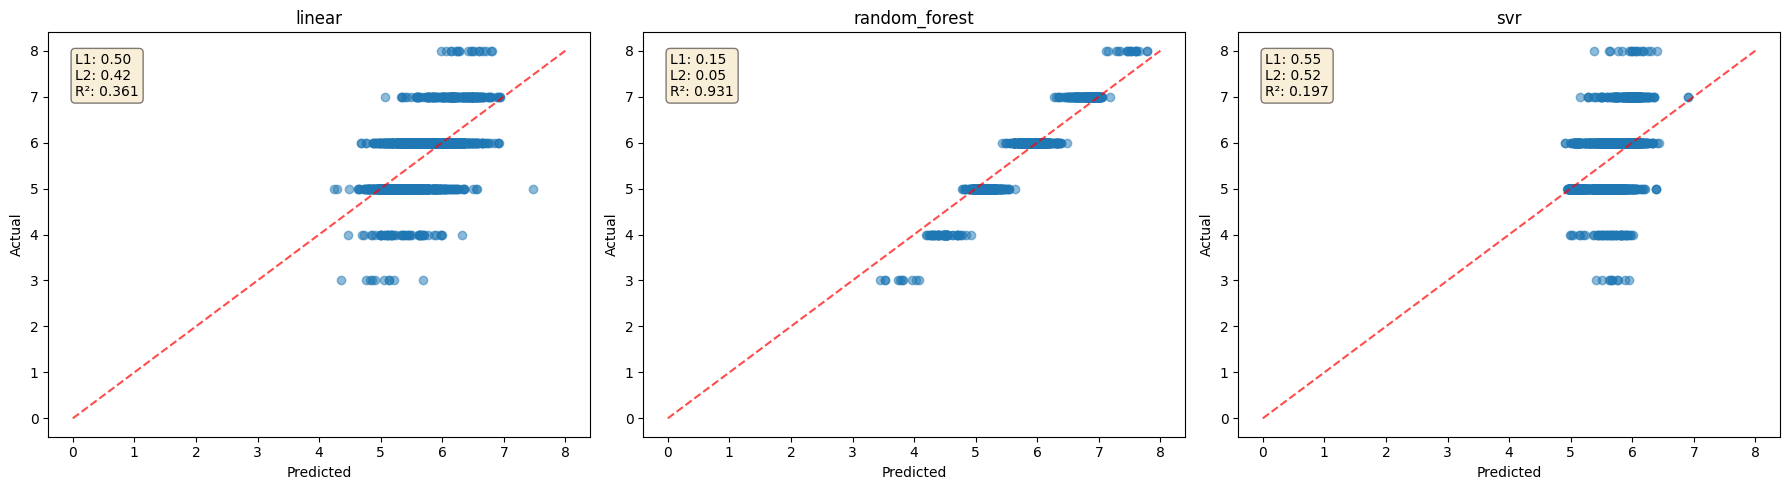

In [596]:

def run_model(model_type: ModelType, X, y) -> ModelResult:
    """Train model and return predictions with metrics."""
    # Train and predict
    model = get_model(model_type)
    model_name = str(type(model))[8:-2]
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Calculate losses
    l1 = mean_absolute_error(y, y_pred)
    l2 = mean_squared_error(y, y_pred)
    
    # Get score
    r2 = model.score(X, y)
    
    return ModelResult(
        model_name=model_type.value,
        predictions=y_pred,
        target=target,
        l1_loss=l1,
        l2_loss=l2,
        r2_score=r2
    )

target = data['target']
features = data.drop(columns=['target',], axis=1)
X = features
y = target

p6_results = {}
ModelResult.clear_results('P6')
for model_type in selected_models:
    result = run_model(model_type, X, y)
    p6_results[model_type] = result
    ModelResult.append_to_results(result, 'P6')

results_summary('P6')
plot_multiple_models(list(p6_results.values()))




YOUR ANSWERS HERE

### Problem 7 (30 points)

Use 5-fold cross-validation to repeat building the same three kinds of regression models. Compare the L2 losses predicted by cross-validation against the L2 losses training against the whole data set. (The difference is likely from overfitting in the latter.)

P7 Results - Sorted by L2 Loss


,Label,description,Model,L1 Loss,L2 Loss,R2 Score
4,P7,P7 (CV),random_forest,0.417182,0.335334,0.482209
3,P7,P7 (CV),linear,0.506845,0.428125,0.339621
5,P7,P7 (CV),svr,0.558201,0.543655,0.163274




SUMMARY: Models That Changed Performance (L2 Loss) After Cross-Validation (P6 vs P7)

linear               | P6: 0.416767 | P7: 0.428125 | Diff: +0.011358 | Change: +2.73% | Changed: YES
random_forest        | P6: 0.045205 | P7: 0.335334 | Diff: +0.290129 | Change: +641.81% | Changed: YES
svr                  | P6: 0.523133 | P7: 0.543655 | Diff: +0.020522 | Change: +3.92% | Changed: YES



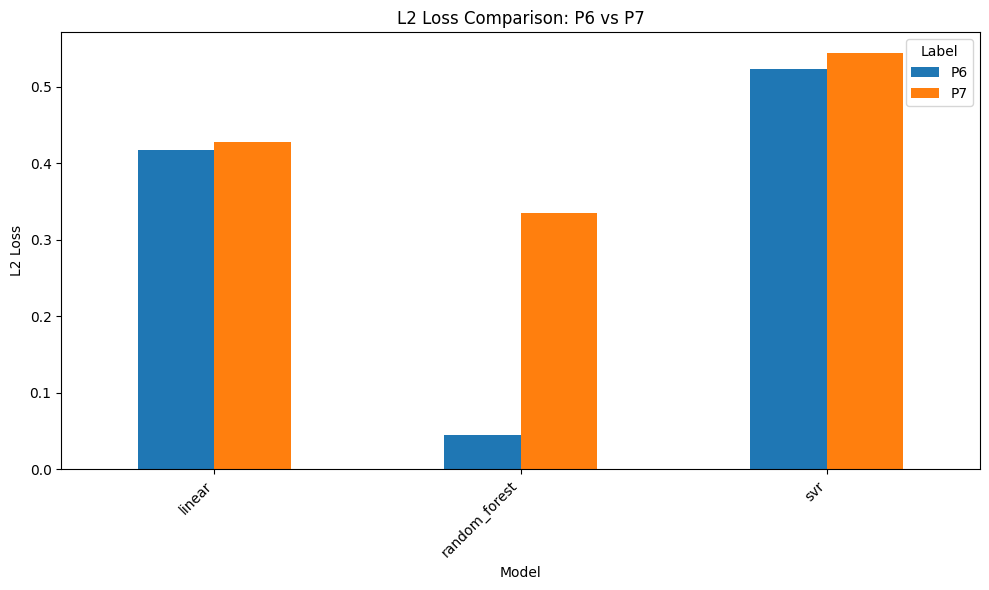


SUMMARY: Models That Changed Performance (R2 Score) After Cross-Validation (P6 vs P7)

linear               | P6: 0.360552 | P7: 0.339621 | Diff: -0.020931 | Change: -5.81% | Changed: YES
random_forest        | P6: 0.930642 | P7: 0.482209 | Diff: -0.448433 | Change: -48.19% | Changed: YES
svr                  | P6: 0.197354 | P7: 0.163274 | Diff: -0.034080 | Change: -17.27% | Changed: YES



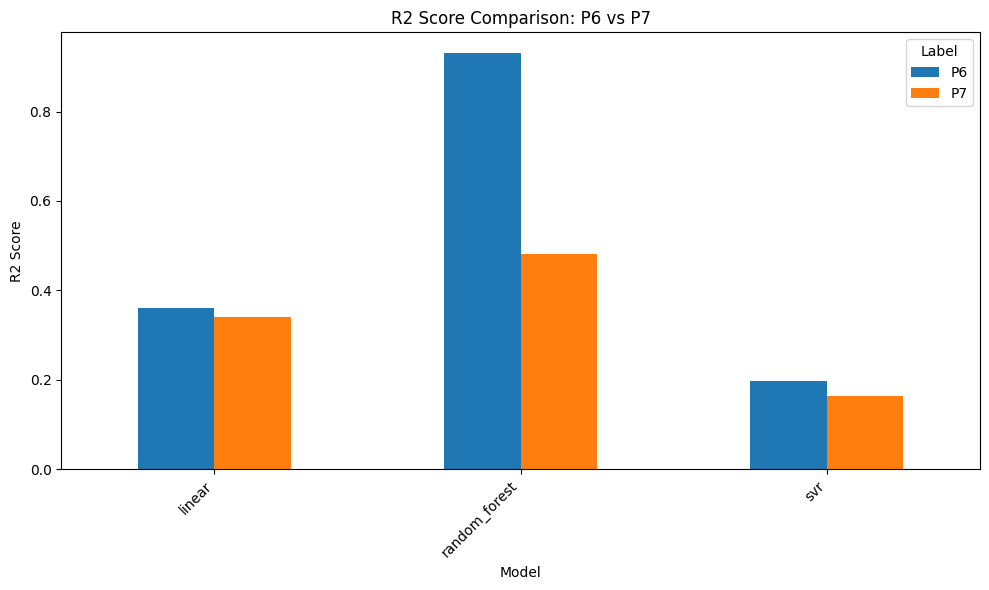

In [597]:

from sklearn.model_selection import cross_val_score, KFold
def run_model_cv(folds, model_type: ModelType, X, y) -> ModelResult:
    """Run k-fold cross-validation for a model and return average metrics."""
    # Train and predict
    model = get_model(model_type)
    model_name = str(type(model))[8:-2]

     
    fold_l1, fold_l2, fold_r2 = [], [], []
    for fold_idx, (train_index, test_index) in enumerate(folds, 1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        l1 = mean_absolute_error(y_test, y_pred)
        l2 = mean_squared_error(y_test, y_pred)
            
        # Get score
        r2 = model.score(X_test, y_test)
        
        fold_l1.append(l1)
        fold_l2.append(l2)
        fold_r2.append(r2)


    
    return ModelResult(
        model_name=model_type.value,
        predictions=None, # does not makes sense in cross-validation
        target=None, # does not makes sense in cross-validation
        l1_loss=np.mean(fold_l1),
        l2_loss=np.mean(fold_l2),
        r2_score=np.mean(fold_r2)
    )


target = data['target']
features = data.drop(columns=['target'], axis=1)
X = features
y = target


fold_size = 5
# setup the folds upfront
# this way each model get the same data on each itration 
kf = KFold(n_splits=fold_size, shuffle=True, random_state=84)
folds = list(kf.split(features)) 

p7_results = {}
ModelResult.clear_results('P7')
for model_type in selected_models:
    result = run_model_cv(folds, model_type, X, y)
    ModelResult.append_to_results(result, 'P7', 'P7 (CV)')
    p7_results[model_type] = result

results_summary('P7')
compare_l2_results_summary('P6', 'P7', 'Cross-Validation')
compare_r2_results_summary('P6', 'P7', 'Cross-Validation')


YOUR ANSWERS HERE

### Problem 8 (25 points)

Build three different regression models as in problem 6, but preprocess the data so that each column has mean zero and standard deviation one first.
For full credit, use a scikit-learn pipeline for each model.
For each model, compare the L2 losses -- which of them performed differently from your results in problem 6?

(This process will be covered in week 13.)

P8 Results - Sorted by L2 Loss


,Label,description,Model,L1 Loss,L2 Loss,R2 Score
7,P8,None,random_forest,0.148186,0.045258,0.930561
8,P8,None,svr,0.383748,0.297437,0.543641
6,P8,None,linear,0.500490,0.416767,0.360552




SUMMARY: Models That Changed Performance (L2 Loss) After Regular Vs Normalized (P6 vs P8)

linear               | P6: 0.416767 | P8: 0.416767 | Diff: -0.000000 | Change: -0.00% | Changed: NO
random_forest        | P6: 0.045205 | P8: 0.045258 | Diff: +0.000053 | Change: +0.12% | Changed: YES
svr                  | P6: 0.523133 | P8: 0.297437 | Diff: -0.225696 | Change: -43.14% | Changed: YES



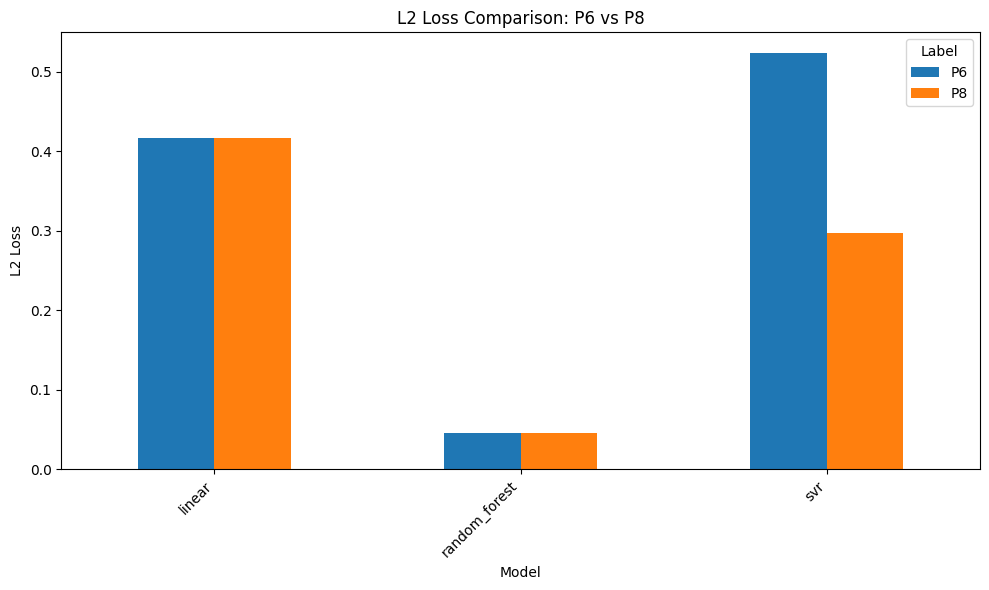


SUMMARY: Models That Changed Performance (R2 Score) After Regular Vs Normalized (P6 vs P8)

linear               | P6: 0.360552 | P8: 0.360552 | Diff: +0.000000 | Change: +0.00% | Changed: NO
random_forest        | P6: 0.930642 | P8: 0.930561 | Diff: -0.000081 | Change: -0.01% | Changed: NO
svr                  | P6: 0.197354 | P8: 0.543641 | Diff: +0.346287 | Change: +175.46% | Changed: YES



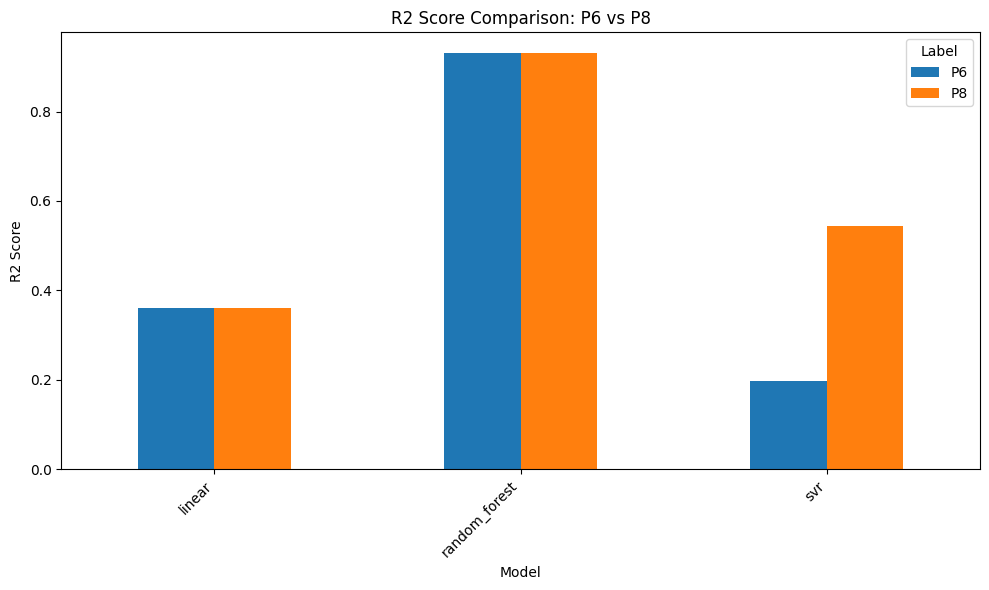

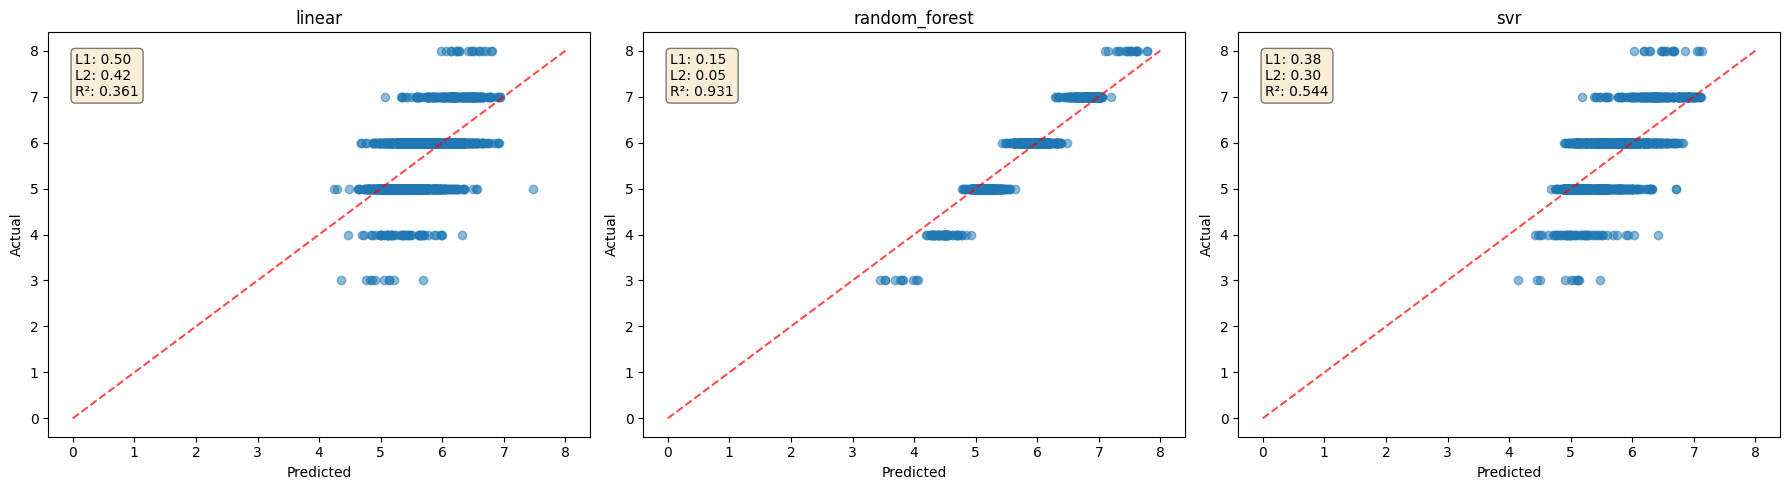

In [598]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def run_model_normalized(model_type: ModelType, X, y) -> ModelResult:
    """Train model and return predictions with metrics. using normalized pipeline"""
    # Train and predict
    model = get_model(model_type)
    model_name = str(type(model))[8:-2]
    pipeline = make_pipeline(StandardScaler(),  model)

    pipeline.fit(X, y)
    y_pred = pipeline.predict(X)

    # X_scaled = pipeline.named_steps['standardscaler'].transform(X)
    # print(f"Scaled X mean: {X_scaled.mean(axis=0)[:3]}")  # Should be ~0
    # print(f"Scaled X std: {X_scaled.std(axis=0)[:3]}")    # Should be ~1
    
    # Calculate losses
    l1 = mean_absolute_error(y, y_pred)
    l2 = mean_squared_error(y, y_pred)
    
    # Get score
    r2 = pipeline.score(X, y)
    
    return ModelResult(
        model_name=model_type.value,
        predictions=y_pred,
        target=y,
        l1_loss=l1,
        l2_loss=l2,
        r2_score=r2
    )



target = data['target']
features = data.drop(columns=['target',], axis=1)
X = features
y = target

ModelResult.clear_results('P8')
p8_results = {}
for model_type in selected_models:
    result = run_model_normalized(model_type, X, y)
    p8_results[model_type] = result
    ModelResult.append_to_results(result, 'P8')

results_summary('P8')
compare_l2_results_summary('P6', 'P8', 'Regular Vs Normalized')
compare_r2_results_summary('P6', 'P8', 'Regular Vs Normalized')
plot_multiple_models(list(p8_results.values()))




YOUR ANSWERS HERE

### Problem 9 (5 points)

A colleague suggests that you find better models by repeatedly building decision trees with random depth limits.
They say that trying 1000 such models will likely find an improvement as long as you use cross validation.
Give a one sentence response to this suggestion. 

#### Answer

Although random search may be effective, systematically evaluating 10 to 20 strategically chosen depth values can achieve comparable performance while significantly reducing computational resources.

### Problem 10 (10 points)

Pick a best model from all the models that you built and otherwise described in this project.
Explain how you picked it, including what criteria you chose, and how the other models compared by that criteria.
As much as possible, justify that problem in the context of the original data set. 

In [600]:
# YOUR CODE HERE

YOUR ANSWERS HERE